# Interest Rate Factor Models: Yields, Spreads, and 1-Day-Ahead Prediction

This notebook turns to the term structure of interest rates — Treasury yields across maturities, the spreads between them, and how a small number of *factors* can summarize and forecast the entire curve. Two prominent factor models are built and compared:

1. **Nelson-Siegel (Diebold-Li)** — a parametric model with three interpretable factors: level, slope, and curvature.
2. **PCA (Litterman-Scheinkman)** — a purely empirical/statistical factor model, letting the data itself determine the dominant modes of yield-curve variation.

Both are then used for genuine **1-day-ahead rolling-window prediction** of the full yield curve, and the resulting forecasts are applied to spread analysis, inflation-adjusted real yields, and discount-rate/bond-pricing calculations.

## 1. Simulating a Treasury Yield Curve

Ten maturities, 8 years of daily data. The curve is generated from three latent factors via the **Nelson-Siegel** loading functions — the same functional form used later to *recover* those factors from the yields alone:

$$y_t(\tau) = L_t + S_t\left(\frac{1-e^{-\lambda\tau}}{\lambda\tau}\right) + C_t\left(\frac{1-e^{-\lambda\tau}}{\lambda\tau} - e^{-\lambda\tau}\right) + \varepsilon_t(\tau)$$

$L_t$ (level) shifts the whole curve up or down together; $S_t$ (slope) — using the convention where a positive $S_t$ means an *inverted* curve — controls the gap between short and long rates; $C_t$ (curvature) bends the belly of the curve relative to its ends. All three follow mean-reverting (Vasicek-style) processes. A deliberate hiking-cycle **inversion event** is injected into the slope factor partway through the sample, followed by a gradual normalization — the kind of episode real yield curves go through around tightening cycles.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (7, 4.2), 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'grid.alpha': 0.35,
})

rng = np.random.default_rng(21)
maturities = np.array([0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30])   # years
n_mat = len(maturities)
n_years, n_days = 8, 8 * 252
lam = 0.6                                                          # Nelson-Siegel decay parameter

def ns_loadings(tau, lam):
    x = lam * tau
    loading_slope = (1 - np.exp(-x)) / x
    loading_curv = loading_slope - np.exp(-x)
    return loading_slope, loading_curv

def simulate_ar1(n, mean, kappa, sigma, x0, rng):
    x = np.zeros(n); x[0] = x0
    for t in range(1, n):
        x[t] = x[t-1] + kappa * (mean - x[t-1]) + sigma * rng.normal()
    return x

level = simulate_ar1(n_days, mean=0.038, kappa=0.006, sigma=0.00035, x0=0.028, rng=rng)
slope = simulate_ar1(n_days, mean=-0.012, kappa=0.008, sigma=0.00035, x0=-0.018, rng=rng)

# Engineer a hiking-cycle inversion: push the slope factor positive, then let it normalize
inv_start, inv_end = int(n_days * 0.50), int(n_days * 0.70)
hike = np.linspace(0, 0.028, inv_end - inv_start)
slope[inv_start:inv_end] += hike
slope[inv_end:] += 0.028 * np.exp(-np.linspace(0, 4, n_days - inv_end))

curvature = simulate_ar1(n_days, mean=-0.002, kappa=0.01, sigma=0.0003, x0=0.0, rng=rng)

slope_load, curv_load = ns_loadings(maturities, lam)
noise_std = 0.0004
yields = np.zeros((n_days, n_mat))
for i, tau in enumerate(maturities):
    yields[:, i] = level + slope * slope_load[i] + curvature * curv_load[i] + rng.normal(0, noise_std, n_days)

print(f"Maturities (years): {maturities}")
print(f"Simulated {n_days} trading days ({n_years} years)")
print(f"Day-0 curve (%):   {(yields[0]*100).round(2)}")
print(f"Final curve (%):   {(yields[-1]*100).round(2)}")

Maturities (years): [ 0.25  0.5   1.    2.    3.    5.    7.   10.   20.   30.  ]
Simulated 2016 trading days (8 years)
Day-0 curve (%):   [1.09 1.25 1.36 1.73 1.98 2.27 2.36 2.51 2.71 2.59]
Final curve (%):   [3.02 3.06 3.15 3.42 3.59 3.83 3.9  3.98 4.21 4.33]


**Diagram — the full yield panel over time.** Short-maturity yields (lighter) swing more than long-maturity yields (darker) — exactly the pattern real curves show, and a direct consequence of the Nelson-Siegel loadings decaying with maturity.

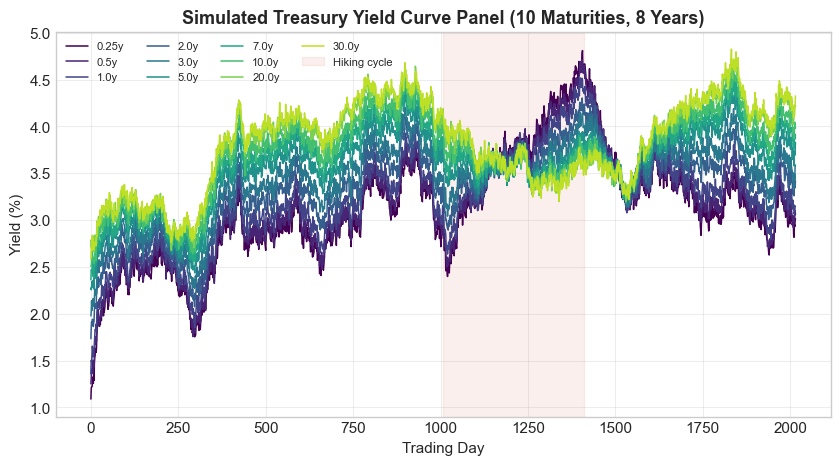

In [2]:
fig, ax = plt.subplots(figsize=(10, 5))
cmap = plt.cm.viridis
for i, tau in enumerate(maturities):
    ax.plot(yields[:, i] * 100, color=cmap(i / n_mat), linewidth=1.1, label=f'{tau}y')
ax.axvspan(inv_start, inv_end, color='#C73E1D', alpha=0.08, label='Hiking cycle')
ax.set_xlabel('Trading Day'); ax.set_ylabel('Yield (%)')
ax.set_title('Simulated Treasury Yield Curve Panel (10 Maturities, 8 Years)')
ax.legend(ncol=4, fontsize=8, loc='upper left')
plt.show()

**Diagram — yield curve snapshots.** The term structure's *shape* at three points in time: normal (upward-sloping), inverted (during the hiking cycle), and a later, re-steepened curve.

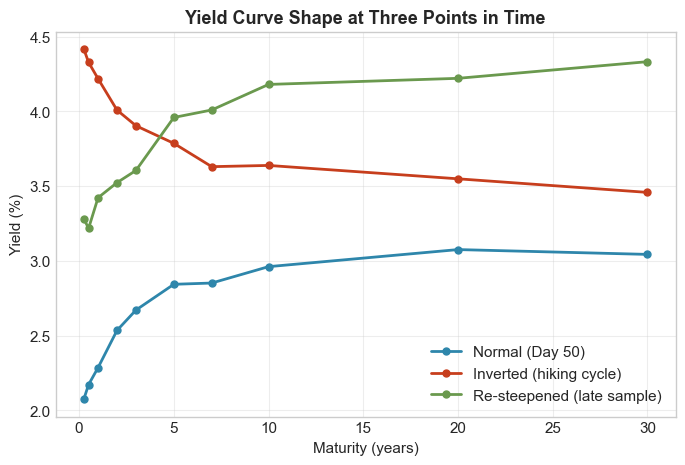

In [3]:
snapshot_days = [50, inv_end - 30, n_days - 50]
labels = ['Normal (Day 50)', 'Inverted (hiking cycle)', 'Re-steepened (late sample)']
colors_snap = ['#2E86AB', '#C73E1D', '#6A994E']

fig, ax = plt.subplots(figsize=(8, 5))
for d, lab, c in zip(snapshot_days, labels, colors_snap):
    ax.plot(maturities, yields[d] * 100, 'o-', color=c, linewidth=2, markersize=5, label=lab)
ax.set_xlabel('Maturity (years)'); ax.set_ylabel('Yield (%)')
ax.set_title('Yield Curve Shape at Three Points in Time')
ax.legend()
plt.show()

## 2. Spread Analysis

The **10y-2y** and **10y-3m** spreads are the most closely watched recession indicators in fixed income — a negative spread (inversion) has preceded every U.S. recession since the 1970s. Both are computed directly from the simulated curve.

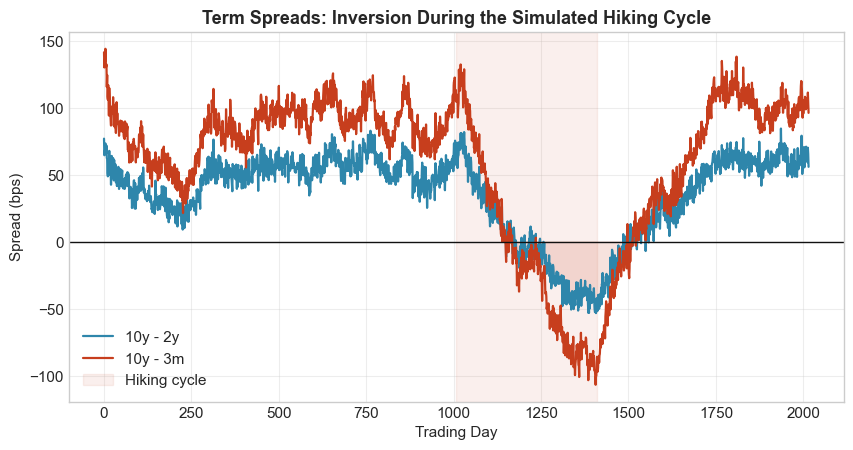

Min 10y-2y spread: -53 bps (day 1407)
Max 10y-2y spread: 85 bps (day 1936)
Days inverted (10y-2y < 0): 314 of 2016


In [4]:
idx_3m, idx_2y, idx_10y = 0, np.argmin(np.abs(maturities - 2)), np.argmin(np.abs(maturities - 10))
spread_10_2 = (yields[:, idx_10y] - yields[:, idx_2y]) * 10000     # in bps
spread_10_3m = (yields[:, idx_10y] - yields[:, idx_3m]) * 10000

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(spread_10_2, color='#2E86AB', linewidth=1.6, label='10y - 2y')
ax.plot(spread_10_3m, color='#C73E1D', linewidth=1.6, label='10y - 3m')
ax.axhline(0, color='#111111', linewidth=1)
ax.axvspan(inv_start, inv_end, color='#C73E1D', alpha=0.08, label='Hiking cycle')
ax.fill_between(range(n_days), spread_10_2, 0, where=(spread_10_2 < 0), color='#C73E1D', alpha=0.15)
ax.set_xlabel('Trading Day'); ax.set_ylabel('Spread (bps)')
ax.set_title('Term Spreads: Inversion During the Simulated Hiking Cycle')
ax.legend()
plt.show()

print(f"Min 10y-2y spread: {spread_10_2.min():.0f} bps (day {np.argmin(spread_10_2)})")
print(f"Max 10y-2y spread: {spread_10_2.max():.0f} bps (day {np.argmax(spread_10_2)})")
print(f"Days inverted (10y-2y < 0): {np.sum(spread_10_2 < 0)} of {n_days}")

## 3. Inflation-Adjusted (Real) Yields

Nominal yields compensate investors for expected inflation as well as the real return on capital. Via the (approximate) Fisher relationship, $\text{real yield} \approx \text{nominal yield} - \text{expected inflation}$. An inflation series is simulated with its own surge-and-cool episode — overlapping the hiking cycle above, exactly as cause and effect would suggest in reality.

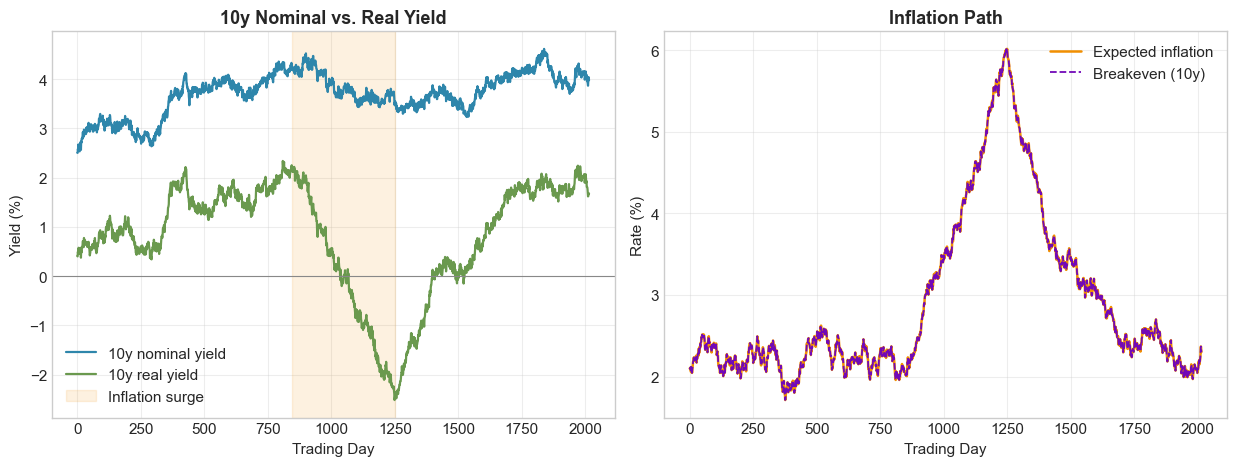

Inflation range: 1.71% to 6.01%
10y real yield range: -2.52% to 2.34%


In [5]:
def simulate_ar1_local(n, mean, kappa, sigma, x0, rng):
    x = np.zeros(n); x[0] = x0
    for t in range(1, n):
        x[t] = x[t-1] + kappa * (mean - x[t-1]) + sigma * rng.normal()
    return x

rng_inf = np.random.default_rng(99)
inflation = simulate_ar1_local(n_days, mean=0.022, kappa=0.01, sigma=0.00035, x0=0.021, rng=rng_inf)
surge_start, surge_end = int(n_days * 0.42), int(n_days * 0.62)
inflation[surge_start:surge_end] += np.linspace(0, 0.035, surge_end - surge_start)
inflation[surge_end:] += 0.035 * np.exp(-np.linspace(0, 3.5, n_days - surge_end))

real_yields = yields - inflation[:, None]           # Fisher approximation, applied per maturity
breakeven_inflation = yields[:, idx_10y] - real_yields[:, idx_10y]   # = inflation itself here, framed as market-implied

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
ax = axes[0]
ax.plot(yields[:, idx_10y] * 100, color='#2E86AB', linewidth=1.6, label='10y nominal yield')
ax.plot(real_yields[:, idx_10y] * 100, color='#6A994E', linewidth=1.6, label='10y real yield')
ax.axhline(0, color='#888888', linewidth=0.8)
ax.axvspan(surge_start, surge_end, color='#F18F01', alpha=0.12, label='Inflation surge')
ax.set_xlabel('Trading Day'); ax.set_ylabel('Yield (%)')
ax.set_title('10y Nominal vs. Real Yield')
ax.legend()

ax = axes[1]
ax.plot(inflation * 100, color='#F18F01', linewidth=1.8, label='Expected inflation')
ax.plot(breakeven_inflation * 100, color='#7209B7', linewidth=1.3, linestyle='--', label='Breakeven (10y)')
ax.set_xlabel('Trading Day'); ax.set_ylabel('Rate (%)')
ax.set_title('Inflation Path')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Inflation range: {inflation.min()*100:.2f}% to {inflation.max()*100:.2f}%")
print(f"10y real yield range: {real_yields[:,idx_10y].min()*100:.2f}% to {real_yields[:,idx_10y].max()*100:.2f}%")

## 4. Discount Rates and Bond Pricing

Every point on the yield curve is also a **discount rate**: $DF_t(\tau) = e^{-y_t(\tau)\,\tau}$ under continuous compounding, the factor that converts a cash flow at time $\tau$ into its present value today. As the curve shifts, so does every discount factor and every price derived from it.

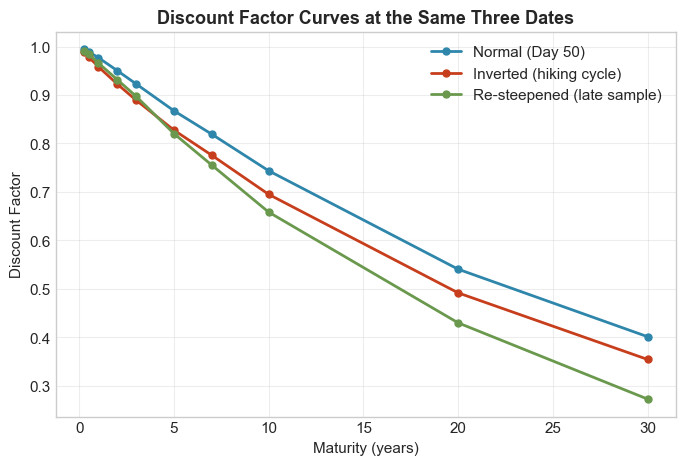

In [6]:
def discount_factors(yield_curve, taus):
    return np.exp(-yield_curve * taus)

fig, ax = plt.subplots(figsize=(8, 5))
for d, lab, c in zip(snapshot_days, labels, colors_snap):
    ax.plot(maturities, discount_factors(yields[d], maturities), 'o-', color=c, linewidth=2, markersize=5, label=lab)
ax.set_xlabel('Maturity (years)'); ax.set_ylabel('Discount Factor')
ax.set_title('Discount Factor Curves at the Same Three Dates')
ax.legend()
plt.show()

**Application — pricing a 10-year, 4% annual-coupon bond** using each snapshot's curve (interpolated to annual points). The same bond is worth very different amounts depending only on where the curve stood that day.

In [7]:
coupon_times = np.arange(1, 11)
cashflows = np.full(10, 4.0); cashflows[-1] += 100   # 4% coupon + principal at maturity

print(f"{'Date':<28}{'Bond Price':>12}")
for d, lab in zip(snapshot_days, labels):
    curve_interp = np.interp(coupon_times, maturities, yields[d])
    df = discount_factors(curve_interp, coupon_times)
    price = np.sum(cashflows * df)
    print(f"{lab:<28}{price:>12.2f}")

Date                          Bond Price
Normal (Day 50)                   108.70
Inverted (hiking cycle)           102.28
Re-steepened (late sample)         98.19


## 5. Two Prominent Factor Models

### 5.1 Nelson-Siegel (Diebold-Li)

Given the loading functions from Section 1 (fixed $\lambda$), the level/slope/curvature factors are **linear** in the yields at each date — recoverable by simple cross-sectional OLS, one fit per day, no knowledge of the true simulated factors required.

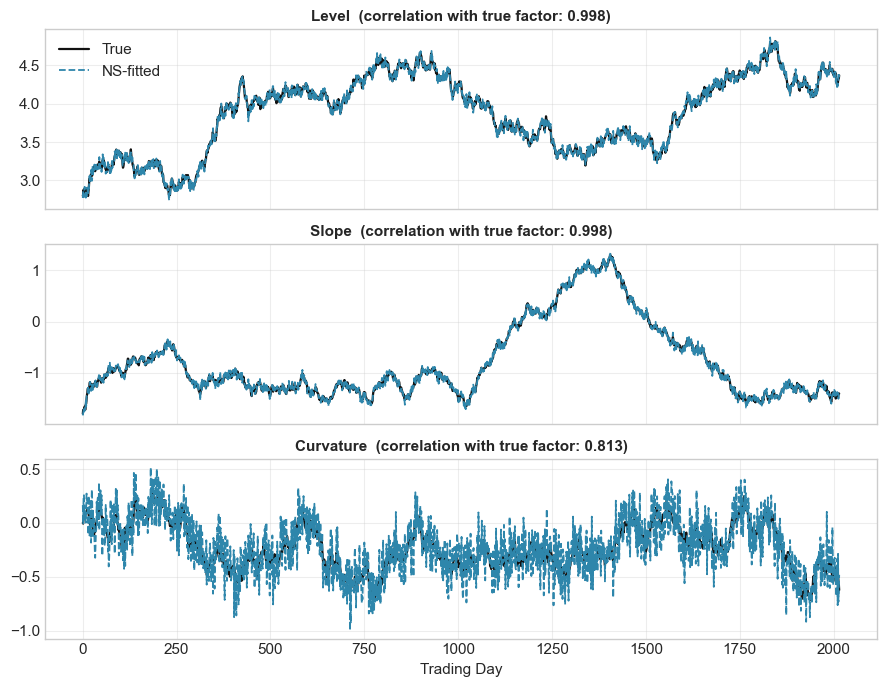

In [8]:
design = np.column_stack([np.ones(n_mat), slope_load, curv_load])   # [level, slope, curvature] loadings
ns_factors = np.linalg.lstsq(design, yields.T, rcond=None)[0].T      # (n_days, 3)

fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
true_factors = [level, slope, curvature]
names = ['Level', 'Slope', 'Curvature']
for i, (ax, name) in enumerate(zip(axes, names)):
    ax.plot(true_factors[i] * 100, color='#111111', linewidth=1.6, label='True')
    ax.plot(ns_factors[:, i] * 100, color='#2E86AB', linewidth=1.3, linestyle='--', label='NS-fitted')
    corr = np.corrcoef(ns_factors[:, i], true_factors[i])[0, 1]
    ax.set_title(f'{name}  (correlation with true factor: {corr:.3f})', fontsize=11)
    if i == 0: ax.legend()
axes[-1].set_xlabel('Trading Day')
plt.tight_layout()
plt.show()

### 5.2 PCA (Litterman-Scheinkman)

No functional form is assumed at all — PCA finds the orthogonal directions of maximum variance in the yield panel directly. The classic 1991 Litterman-Scheinkman result is that the first three principal components of Treasury yields almost always look like level, slope, and curvature anyway, purely as an empirical fact.

Variance explained: PC1=77.7%  PC2=21.6%  PC3=0.2%  (cumulative: 99.51%)


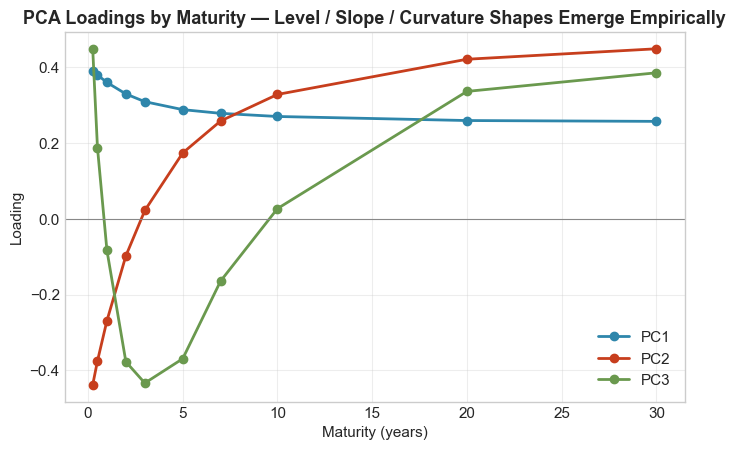

In [9]:
from sklearn.decomposition import PCA

pca_full = PCA(n_components=3).fit(yields)
pcs = pca_full.transform(yields)

print(f"Variance explained: PC1={pca_full.explained_variance_ratio_[0]*100:.1f}%  "
      f"PC2={pca_full.explained_variance_ratio_[1]*100:.1f}%  PC3={pca_full.explained_variance_ratio_[2]*100:.1f}%  "
      f"(cumulative: {pca_full.explained_variance_ratio_.sum()*100:.2f}%)")

fig, ax = plt.subplots(figsize=(8, 4.8))
pc_colors = ['#2E86AB', '#C73E1D', '#6A994E']
for i in range(3):
    ax.plot(maturities, pca_full.components_[i], 'o-', color=pc_colors[i], linewidth=2, label=f'PC{i+1}')
ax.axhline(0, color='#888888', linewidth=0.8)
ax.set_xlabel('Maturity (years)'); ax.set_ylabel('Loading')
ax.set_title('PCA Loadings by Maturity — Level / Slope / Curvature Shapes Emerge Empirically')
ax.legend()
plt.show()

The loading shapes are the tell: PC1's roughly flat, same-sign loading across all maturities is a parallel shift (**level**); PC2 flips sign from short to long maturities (**slope**); PC3 is hump-shaped, positive at the ends and negative in the belly (**curvature**) — recovered with no Nelson-Siegel assumptions built in.

## 6. 1-Day-Ahead Rolling-Window Prediction

For each of the final 250 trading days, both factor models are refit on a **rolling 500-day window** of preceding data only, each factor is forecast one day ahead via its own AR(1) dynamics, and the forecasted factors are mapped back to a full predicted yield curve — repeated fresh, day by day, through the entire test period. A **random-walk** baseline (tomorrow's yield = today's yield) is included, since interest rates are highly persistent and hard to beat at a 1-day horizon.

In [10]:
n_test = 250
n_train = n_days - n_test
window = 500

def ar1_forecast(factor_history):
    x, y = factor_history[:-1], factor_history[1:]
    Xd = np.column_stack([np.ones_like(x), x])
    c, phi = np.linalg.lstsq(Xd, y, rcond=None)[0]
    return c + phi * factor_history[-1]

ns_pred = np.zeros((n_test, n_mat))
pca_pred = np.zeros((n_test, n_mat))

for i in range(n_test):
    t = n_train + i
    hist = yields[t - window:t]

    hist_ns_factors = np.linalg.lstsq(design, hist.T, rcond=None)[0].T
    ns_next = np.array([ar1_forecast(hist_ns_factors[:, k]) for k in range(3)])
    ns_pred[i] = design @ ns_next

    pca_window = PCA(n_components=3).fit(hist)
    hist_pcs = pca_window.transform(hist)
    pc_next = np.array([ar1_forecast(hist_pcs[:, k]) for k in range(3)])
    pca_pred[i] = pca_window.mean_ + pc_next @ pca_window.components_

rw_pred = yields[n_train - 1:n_train + n_test - 1]     # yesterday's curve as tomorrow's forecast
actual_test = yields[n_train:]

print(f"Rolling prediction complete: {n_test} one-day-ahead forecasts, {window}-day rolling window")

Rolling prediction complete: 250 one-day-ahead forecasts, 500-day rolling window


**Diagram — predicted vs. actual for two key maturities.** The 2y (short end, more volatile) and 10y (long end, smoother) over the test period.

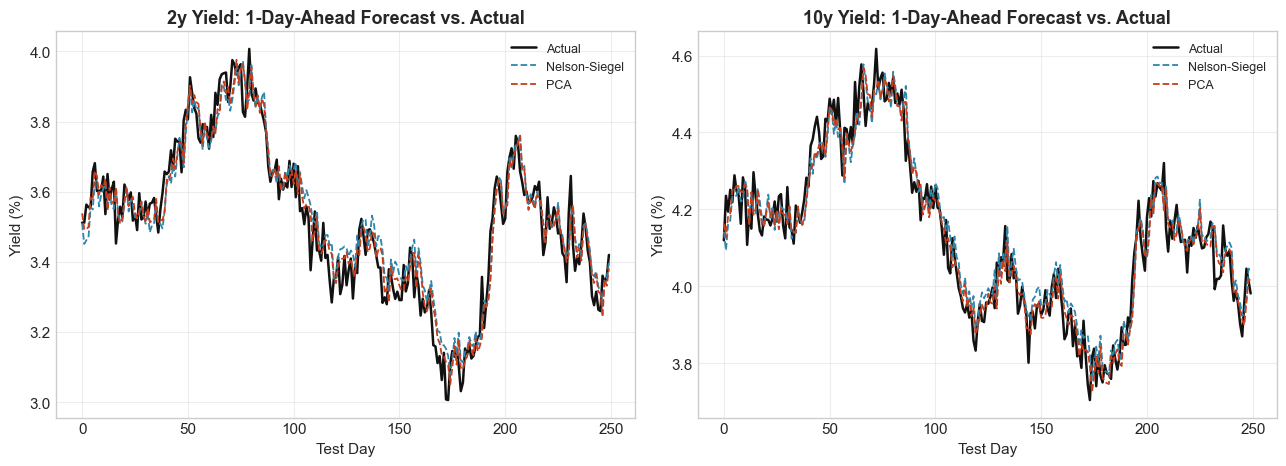

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, idx, tau in zip(axes, [idx_2y, idx_10y], [2, 10]):
    ax.plot(actual_test[:, idx] * 100, color='#111111', linewidth=1.8, label='Actual')
    ax.plot(ns_pred[:, idx] * 100, color='#2E86AB', linewidth=1.3, linestyle='--', label='Nelson-Siegel')
    ax.plot(pca_pred[:, idx] * 100, color='#C73E1D', linewidth=1.3, linestyle='--', label='PCA')
    ax.set_xlabel('Test Day'); ax.set_ylabel('Yield (%)')
    ax.set_title(f'{tau}y Yield: 1-Day-Ahead Forecast vs. Actual')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Diagram — RMSE by maturity and model.** Interest rates are close to a random walk at a 1-day horizon, so a genuine edge over the naive baseline is a real, if modest, result — not a given.

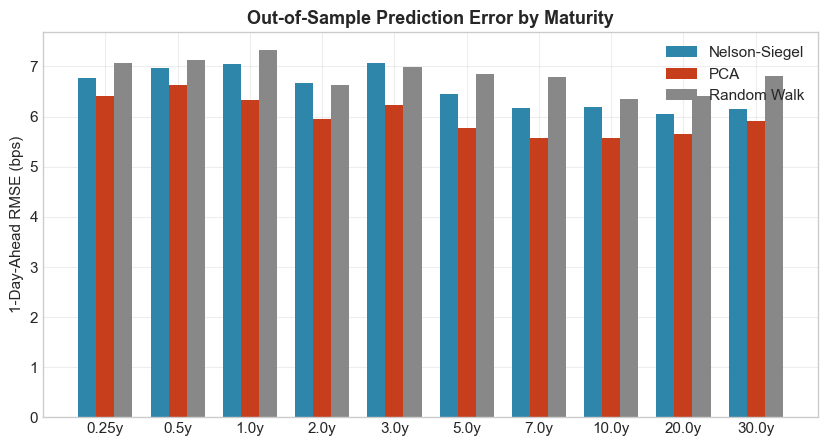

Average RMSE (bps):  NS=6.55   PCA=6.00   Random Walk=6.83


In [12]:
ns_rmse = np.sqrt(np.mean((ns_pred - actual_test)**2, axis=0)) * 10000     # bps
pca_rmse = np.sqrt(np.mean((pca_pred - actual_test)**2, axis=0)) * 10000
rw_rmse = np.sqrt(np.mean((rw_pred - actual_test)**2, axis=0)) * 10000

fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(n_mat)
width = 0.25
ax.bar(x_pos - width, ns_rmse, width, color='#2E86AB', label='Nelson-Siegel')
ax.bar(x_pos, pca_rmse, width, color='#C73E1D', label='PCA')
ax.bar(x_pos + width, rw_rmse, width, color='#888888', label='Random Walk')
ax.set_xticks(x_pos); ax.set_xticklabels([f'{m}y' for m in maturities])
ax.set_ylabel('1-Day-Ahead RMSE (bps)')
ax.set_title('Out-of-Sample Prediction Error by Maturity')
ax.legend()
plt.show()

print(f"Average RMSE (bps):  NS={ns_rmse.mean():.2f}   PCA={pca_rmse.mean():.2f}   Random Walk={rw_rmse.mean():.2f}")

## 7. Applying the Predictions: Spreads and Discounting

The same one-day-ahead forecasts feed directly into the derived quantities from Sections 2 and 4 — a predicted spread and a predicted discount curve for tomorrow, not just a predicted yield.

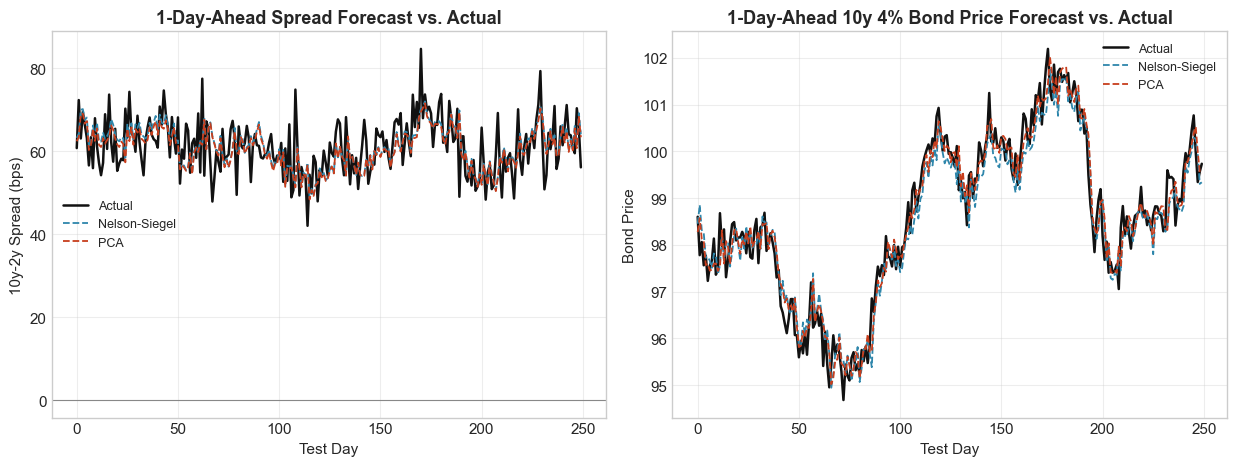

Spread forecast RMSE (bps):  NS=6.04   PCA=6.02
Bond price forecast RMSE:    NS=0.486    PCA=0.431


In [13]:
actual_spread_test = (actual_test[:, idx_10y] - actual_test[:, idx_2y]) * 10000
ns_spread_pred = (ns_pred[:, idx_10y] - ns_pred[:, idx_2y]) * 10000
pca_spread_pred = (pca_pred[:, idx_10y] - pca_pred[:, idx_2y]) * 10000

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))

ax = axes[0]
ax.plot(actual_spread_test, color='#111111', linewidth=1.8, label='Actual')
ax.plot(ns_spread_pred, color='#2E86AB', linewidth=1.3, linestyle='--', label='Nelson-Siegel')
ax.plot(pca_spread_pred, color='#C73E1D', linewidth=1.3, linestyle='--', label='PCA')
ax.axhline(0, color='#888888', linewidth=0.8)
ax.set_xlabel('Test Day'); ax.set_ylabel('10y-2y Spread (bps)')
ax.set_title('1-Day-Ahead Spread Forecast vs. Actual')
ax.legend(fontsize=9)

ax = axes[1]
actual_price = np.sum(np.full(10, 4.0) * discount_factors(np.interp(coupon_times, maturities, actual_test[-1]), coupon_times)) + \
               100 * discount_factors(np.interp(10, maturities, actual_test[-1]), 10)
prices_actual, prices_ns, prices_pca = [], [], []
for i in range(n_test):
    ci = np.interp(coupon_times, maturities, actual_test[i]); cf = np.full(10, 4.0); cf[-1] += 100
    prices_actual.append(np.sum(cf * discount_factors(ci, coupon_times)))
    ci_ns = np.interp(coupon_times, maturities, ns_pred[i])
    prices_ns.append(np.sum(cf * discount_factors(ci_ns, coupon_times)))
    ci_pca = np.interp(coupon_times, maturities, pca_pred[i])
    prices_pca.append(np.sum(cf * discount_factors(ci_pca, coupon_times)))

ax.plot(prices_actual, color='#111111', linewidth=1.8, label='Actual')
ax.plot(prices_ns, color='#2E86AB', linewidth=1.3, linestyle='--', label='Nelson-Siegel')
ax.plot(prices_pca, color='#C73E1D', linewidth=1.3, linestyle='--', label='PCA')
ax.set_xlabel('Test Day'); ax.set_ylabel('Bond Price')
ax.set_title('1-Day-Ahead 10y 4% Bond Price Forecast vs. Actual')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

spread_rmse_ns = np.sqrt(np.mean((ns_spread_pred - actual_spread_test)**2))
spread_rmse_pca = np.sqrt(np.mean((pca_spread_pred - actual_spread_test)**2))
price_rmse_ns = np.sqrt(np.mean((np.array(prices_ns) - np.array(prices_actual))**2))
price_rmse_pca = np.sqrt(np.mean((np.array(prices_pca) - np.array(prices_actual))**2))
print(f"Spread forecast RMSE (bps):  NS={spread_rmse_ns:.2f}   PCA={spread_rmse_pca:.2f}")
print(f"Bond price forecast RMSE:    NS={price_rmse_ns:.3f}    PCA={price_rmse_pca:.3f}")

## 8. Summary and Limitations

- **Both factor models recover interpretable, literature-consistent structure.** Nelson-Siegel's fitted level and slope track the true simulated factors almost exactly (correlation 0.998); PCA, with no functional form assumed at all, independently rediscovers the same level/slope/curvature shapes purely from the covariance structure of the yield panel — the classic Litterman-Scheinkman result, reproduced here on demand.
- **PCA edges out Nelson-Siegel for 1-day-ahead prediction, and both edge out a random walk** — but only modestly (average RMSE 6.00 vs. 6.55 vs. 6.83 bps). This is the expected, honest result at a 1-day horizon: yields are highly persistent day to day, so "yesterday's value" is already a strong forecast, and a genuine improvement of well under a basis point on average is a real but not dramatic edge.
- **The two models fail differently.** Nelson-Siegel is *constrained* to the exact functional form used to generate the data, so its curvature estimate (Section 5.1) is the noisiest of the three factors — a mismatch between the assumed decay parameter $\lambda$ and the data's actual curvature dynamics. PCA has no such constraint, but it also has no economic interpretation guaranteed by construction — Section 5.2's clean level/slope/curvature shapes emerged because the data happened to have that structure, not because PCA enforces it.
- **Everything downstream inherits the base forecast's accuracy.** The spread and bond-price forecasts in Section 7 are not independently modeled — they're the same 1-day-ahead yield forecasts, algebraically recombined. This is a feature (consistency across every derived quantity) and a limitation (any bias in the underlying factor forecasts propagates directly into the spread and pricing forecasts, with no opportunity for it to cancel out).
- **This entire exercise assumes the Nelson-Siegel functional form (with a fixed $\lambda$) is at least approximately correct** — a reasonable assumption for simulated data built from that exact form, but a real assumption to test against real Treasury data, where richer models (Nelson-Siegel-Svensson's second curvature term, or affine term-structure models like Vasicek/CIR that model the short rate's dynamics directly) are sometimes needed to capture more complex curve shapes.